In [ ]:
import sys
import pandas as pd

# Add load_hx_data location
sys.path.insert(0, r'C:\Users\manognas\OneDrive - Michigan Medicine\Desktop\range_3324350-datatype_4096-1006\record_308166')

import load_hx_data
load_hx_data.set_device_model('hx')

# Load ECG WAV file
ecg_data = load_hx_data.load_wave(r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\range_3324355-datatype_4096-1006\record_308168\ECG_I.wav')
# Convert to DataFrame
ecg = pd.DataFrame(ecg_data, columns=['time', 'ECG'])

print(ecg.head())

       time     ECG
0  0.000000  2.8608
1  0.003906  2.8480
2  0.007812  2.9120
3  0.011719  3.0592
4  0.015625  2.8864


In [ ]:
import neurokit2 as nk
# Step 1 — load WAV as DataFrame
ecg = pd.DataFrame(ecg_data, columns=['time', 'ECG'])

# Step 2 — extract numpy array
ecg_numpy = ecg['ECG'].to_numpy()

# Step 3 — pass numpy array into ecg_process
ecg_signals, info = nk.ecg_process(ecg_numpy, sampling_rate=256, method='neurokit')

# Step 4 — view output
print(ecg_signals.head())
print(f"Mean Heart Rate : {ecg_signals['ECG_Rate'].mean():.1f} bpm")
print(f"Total R Peaks   : {ecg_signals['ECG_R_Peaks'].sum()}")

   ECG_Raw  ECG_Clean   ECG_Rate  ECG_Quality  ECG_R_Peaks  ECG_P_Peaks  \
0   2.8608   0.939007  62.681212     0.575166            0            0   
1   2.8480   0.968861  62.681212     0.575166            0            0   
2   2.9120   0.972805  62.681212     0.575166            0            0   
3   3.0592   0.939276  62.681212     0.575166            0            0   
4   2.8864   0.870034  62.681212     0.575166            0            0   

   ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  ECG_R_Onsets  ECG_R_Offsets  \
0             0              0            0             0              0   
1             0              0            0             0              0   
2             0              0            0             0              0   
3             0              0            0             0              0   
4             0              0            0             0              0   

   ECG_S_Peaks  ECG_T_Peaks  ECG_T_Onsets  ECG_T_Offsets  ECG_Phase_Atrial  \
0            0

c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


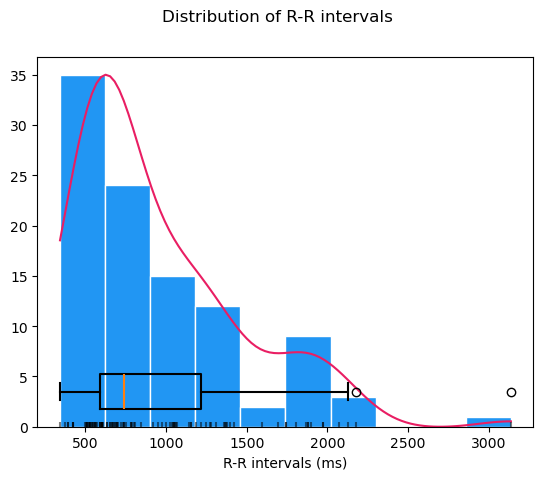

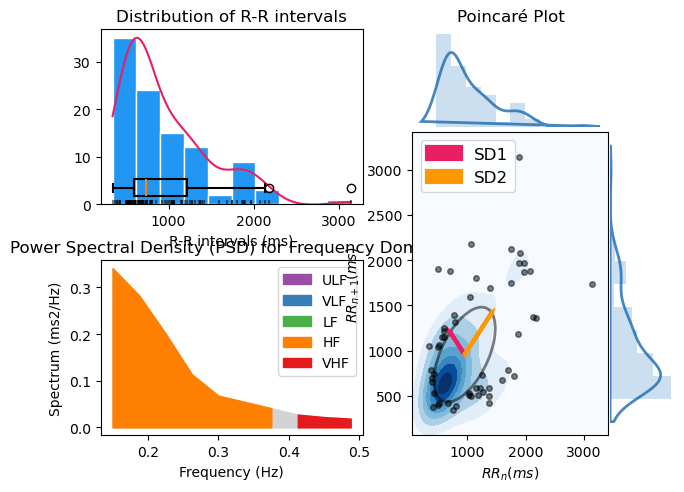

In [ ]:
hrv_time = nk.hrv_time(peaks, sampling_rate = 256, show = True)
hrv_time.head()
hrv_indices = nk.hrv(peaks, sampling_rate = 256, show = True)

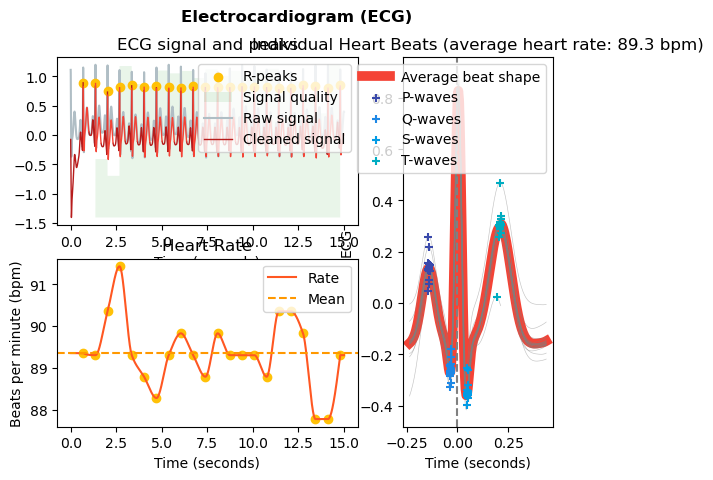

In [ ]:
# Simulate ECG signal
ecg = nk.ecg_simulate(duration=15, sampling_rate=256, heart_rate=89.33)

# Preprocess ECG signal
signals, info = nk.ecg_process(ecg, sampling_rate=256)

# Visualize
nk.ecg_plot(signals, info)

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt


def ecg_i_analysis(folder, sampling_rate=256):
    """
    Analyze ECG_I.wav from a Hexoskin record folder.

    Parameters
    ----------
    folder        : str  — path to the record folder containing ECG_I.wav
    sampling_rate : int  — Hexoskin ECG sampling rate (default 256 Hz)

    Returns
    -------
    ecg_signals   : DataFrame — processed ECG signals
    hrv_time      : DataFrame — time-domain HRV metrics
    hrv_indices   : DataFrame — full HRV (time + frequency + nonlinear)
    hrv_nonlinear : DataFrame — nonlinear HRV metrics
    """

    # Load load_hx_data from the record folder 
    sys.path.insert(0, folder)          
    import load_hx_data
    load_hx_data.set_device_model('hx')

    # Load ECG WAV file  
    ecg_data = load_hx_data.load_wave(folder)

    # Convert to DataFrame  
    ecg = pd.DataFrame(ecg_data, columns=['time', 'ECG'])
    ecg_numpy = ecg['ECG'].to_numpy()

    print(f"[INFO] Loaded ECG — {len(ecg_numpy)} samples @ {sampling_rate} Hz")
    print(f"[INFO] Duration  — {len(ecg_numpy)/sampling_rate:.1f} seconds")

    # Clean + Process ECG  
    ecg_signals, info = nk.ecg_process(ecg_numpy, sampling_rate=sampling_rate, method='neurokit')
    ecg_signals.insert(0, 'time', ecg['time'].values)

    #  Peak detection with artifact correction  
    ecg_cleaned = nk.ecg_clean(ecg_numpy, sampling_rate=sampling_rate)
    peaks, info  = nk.ecg_peaks(
        ecg_cleaned,
        sampling_rate=sampling_rate,
        correct_artifacts=True,
        show=True
    )
    plt.suptitle('R-Peak Detection', fontsize=12)
    plt.tight_layout()
    plt.show()

    # RR intervals from peak times  
    peak_times   = ecg_signals['time'][ecg_signals['ECG_R_Peaks'] == 1].values
    rr_intervals = np.diff(peak_times) * 1000   # seconds → milliseconds

    print(f"\n{'='*50}")
    print(f"  ECG SUMMARY")
    print(f"{'='*50}")
    print(f"  Total R Peaks    : {len(peak_times)}")
    print(f"  Mean Heart Rate  : {ecg_signals['ECG_Rate'].mean():.1f} bpm")
    print(f"  Mean RR interval : {np.mean(rr_intervals):.1f} ms")
    print(f"  HRV SDNN         : {np.std(rr_intervals, ddof=1):.1f} ms")   # ddof=1 for sample std
    print(f"  HRV RMSSD        : {np.sqrt(np.mean(np.diff(rr_intervals)**2)):.1f} ms")
    print(f"{'='*50}\n")

    # HRV — Time Domain  
    hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=True)
    plt.suptitle('HRV Time Domain', fontsize=12)
    plt.tight_layout()
    plt.show()
    print("\n[HRV Time Domain]")
    print(hrv_time.T)   # transpose for readability

    # HRV — Full (time + frequency + nonlinear)  
    hrv_indices = nk.hrv(peaks, sampling_rate=sampling_rate, show=True)
    plt.suptitle('HRV Full Analysis', fontsize=12)
    plt.tight_layout()
    plt.show()

    # HRV — Nonlinear  
    # NOTE: correct parameter is 'show_poincare' not 'SD1_SD2'
    hrv_nonlinear = nk.hrv_nonlinear(peaks, sampling_rate=sampling_rate, show=True)
    plt.suptitle('HRV Nonlinear (Poincaré)', fontsize=12)
    plt.tight_layout()
    plt.show()
    print("\n[HRV Nonlinear]")
    print(hrv_nonlinear.T)

    return ecg_signals, hrv_time, hrv_indices, hrv_nonlinear




[INFO] Loaded ECG — 58880 samples @ 256 Hz
[INFO] Duration  — 230.0 seconds


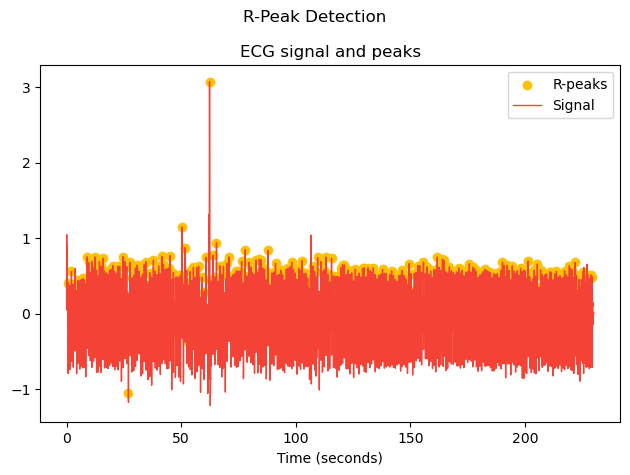


  ECG SUMMARY
  Total R Peaks    : 307
  Mean Heart Rate  : 80.3 bpm
  Mean RR interval : 747.4 ms
  HRV SDNN         : 54.1 ms
  HRV RMSSD        : 30.3 ms



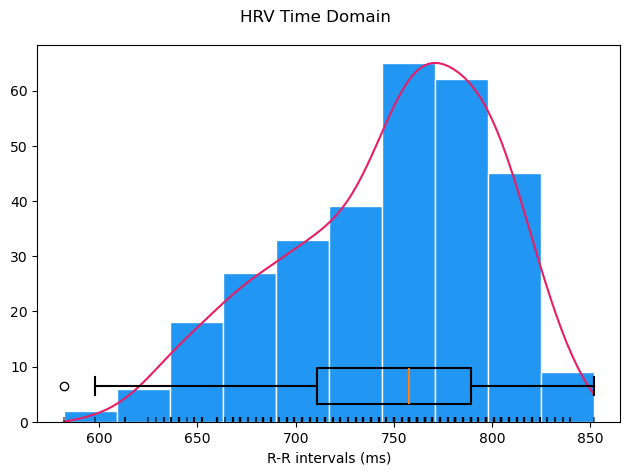


[HRV Time Domain]
                       0
HRV_MeanNN    747.421364
HRV_SDNN       54.056598
HRV_SDANN1     36.768065
HRV_SDNNI1     43.712016
HRV_SDANN2           NaN
HRV_SDNNI2           NaN
HRV_SDANN5           NaN
HRV_SDNNI5           NaN
HRV_RMSSD      30.288255
HRV_SDSD       30.337702
HRV_CVNN        0.072324
HRV_CVSD        0.040524
HRV_MedianNN  757.812500
HRV_MadNN      57.914062
HRV_MCVNN       0.076423
HRV_IQRNN      78.125000
HRV_SDRMSSD     1.784738
HRV_Prc20NN   699.218750
HRV_Prc80NN   796.875000
HRV_pNN50       9.803922
HRV_pNN20      42.156863
HRV_MinNN     582.031250
HRV_MaxNN     851.562500
HRV_HTI        10.200000
HRV_TINN      187.500000


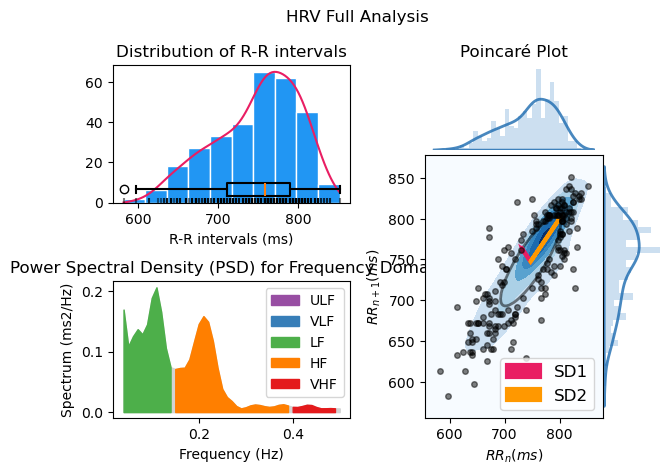

C:\Users\manognas\AppData\Local\Temp\ipykernel_15932\1030569329.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


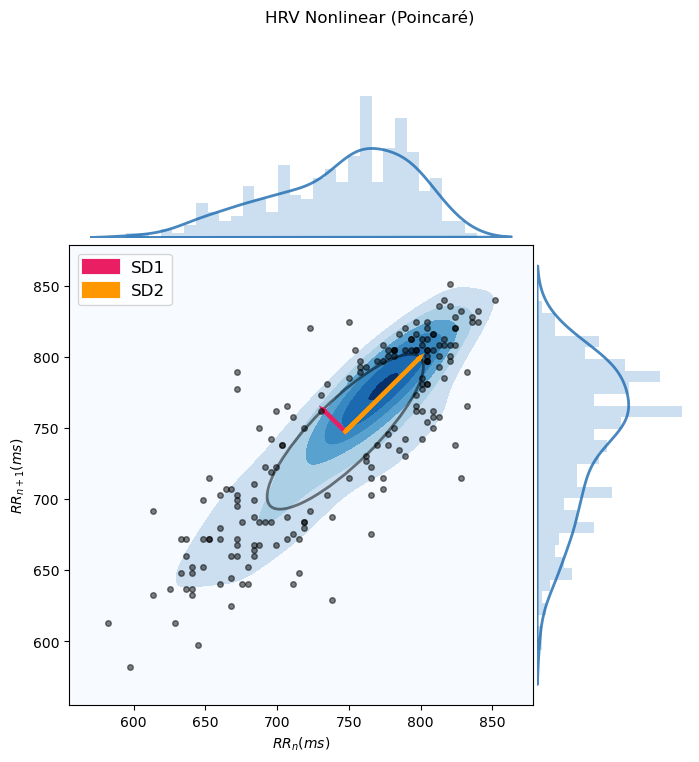


[HRV Nonlinear]
                                        0
HRV_SD1                         21.451995
HRV_SD2                         73.354823
HRV_SD1SD2                       0.292442
HRV_S                         4943.633126
HRV_CSI                          3.419487
HRV_CVI                          4.401016
HRV_CSI_Modified              1003.343508
HRV_PIP                          0.513072
HRV_IALS                         0.480427
HRV_PSS                          0.688889
HRV_PAS                          0.130435
HRV_GI                          49.681897
HRV_SI                          49.664474
HRV_AI                          49.699423
HRV_PI                          47.330961
HRV_C1d                          0.466761
HRV_C1a                          0.533239
HRV_SD1d                        14.656145
HRV_SD1a                        15.665103
HRV_C2d                          0.495113
HRV_C2a                          0.504887
HRV_SD2d                        51.615589
HRV_SD2a         

(             time  ECG_Raw  ECG_Clean   ECG_Rate  ECG_Quality  ECG_R_Peaks  \
 0        0.000000  -0.8576   0.052193  80.276003     0.720612            0   
 1        0.003906  -0.8576   0.153291  80.276003     0.720612            0   
 2        0.007812  -0.7104   0.267445  80.276003     0.720612            0   
 3        0.011719  -0.5184   0.394656  80.276003     0.720612            0   
 4        0.015625  -0.3328   0.530060  80.276003     0.720612            0   
 ...           ...      ...        ...        ...          ...          ...   
 58875  229.980469   0.0640  -0.000513  89.302326     0.995910            0   
 58876  229.984375   0.0640   0.000488  89.302326     0.995910            0   
 58877  229.988281   0.0640   0.002483  89.302326     0.995910            0   
 58878  229.992188   0.0704   0.005223  89.302326     0.995910            0   
 58879  229.996094   0.0768   0.008463  89.302326     0.995910            0   
 
        ECG_P_Peaks  ECG_P_Onsets  ECG_P_Offsets  

In [ ]:
folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\range_3324354-datatype_4096-1006\record_308166\ECG_I.wav'
ecg_i_analysis(folder)

[INFO] Found 82 range folders
[PROCESSING] Participant 308166 - range_3324350-datatype_4096-1006
  RMSSD=107.8  pNN50=51.4  SD1/SD2=0.296
[PROCESSING] Participant 308166 - range_3324351-datatype_4096-1006
  RMSSD=144.0  pNN50=60.0  SD1/SD2=0.410
[PROCESSING] Participant 308166 - range_3324354-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=118.3  pNN50=59.5  SD1/SD2=0.292
[PROCESSING] Participant 308168 - range_3324355-datatype_4096-1006
  RMSSD=920.5  pNN50=55.6  SD1/SD2=0.308
[PROCESSING] Participant 308168 - range_3324409-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=884.7  pNN50=80.6  SD1/SD2=0.431
[PROCESSING] Participant 308168 - range_3324410-datatype_4096-1006
[SKIP] range_3324410-datatype_4096-1006/record_308168 - too few clean RR intervals (17)
[PROCESSING] Participant 308169 - range_3324420-datatype_4096-1006
  RMSSD=348.1  pNN50=22.8  SD1/SD2=0.566
[PROCESSING] Participant 308169 - range_3324421-datatype_4096-1006


...

  RMSSD=25.3  pNN50=5.5  SD1/SD2=0.092
[PROCESSING] Participant 309212 - range_3333668-datatype_4096-1006
  RMSSD=22.2  pNN50=1.9  SD1/SD2=0.083
[PROCESSING] Participant 309212 - range_3333669-datatype_4096-1006
  RMSSD=33.2  pNN50=9.0  SD1/SD2=0.124
[PROCESSING] Participant 309213 - range_3333675-datatype_4096-1006
  RMSSD=116.7  pNN50=62.9  SD1/SD2=0.402
[PROCESSING] Participant 309213 - range_3333676-datatype_4096-1006
  RMSSD=112.1  pNN50=60.6  SD1/SD2=0.147
[PROCESSING] Participant 309213 - range_3333677-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=126.7  pNN50=61.8  SD1/SD2=0.193
[PROCESSING] Participant 309273 - range_3334287-datatype_4096-1006
  RMSSD=27.9  pNN50=6.6  SD1/SD2=0.196
[PROCESSING] Participant 309273 - range_3334288-datatype_4096-1006
  RMSSD=27.6  pNN50=5.8  SD1/SD2=0.199
[PROCESSING] Participant 309273 - range_3334289-datatype_4096-1006
  RMSSD=16.4  pNN50=0.9  SD1/SD2=0.124
[PROCESSING] Participant 309274 - range_3334294-datatype_4096-1006
  RMSSD=89.8  pNN50=55.6  SD1/SD2=0.339
[PROCESSING] Participant 309274 - range_3334295-datatype_4096-1006
  RMSSD=88.5  pNN50=40.0  SD1/SD2=0.243
[PROCESSING] Participant 309274 - range_3334296-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=71.4  pNN50=37.9  SD1/SD2=0.180

[SAVED] Metrics CSV: C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\hrv_metrics_all_participants.csv
participant_id                     range_folder record_folder       RMSSD     pNN50  SD1_SD2_ratio
        308166 range_3324350-datatype_4096-1006 record_308166  107.825477 51.401869       0.295719
        308166 range_3324351-datatype_4096-1006 record_308166  144.048762 60.000000       0.409918
        308166 range_3324354-datatype_4096-1006 record_308166  118.274289 59.477124       0.292320
        308168 range_3324355-datatype_4096-1006 record_308168  920.549142 55.555556       0.307633
        308168 range_3324409-datatype_4096-1006 record_308168  884.736737 80.645161       0.431195
        308169 range_3324420-datatype_4096-1006 record_308169  348.134546 22.772277       0.566443
        308169 range_3324421-datatype_4096-1006 record_308169  638.228680 42.105263       0.269608
        308169 range_3324422-datatype_4096-1006 record_308169  

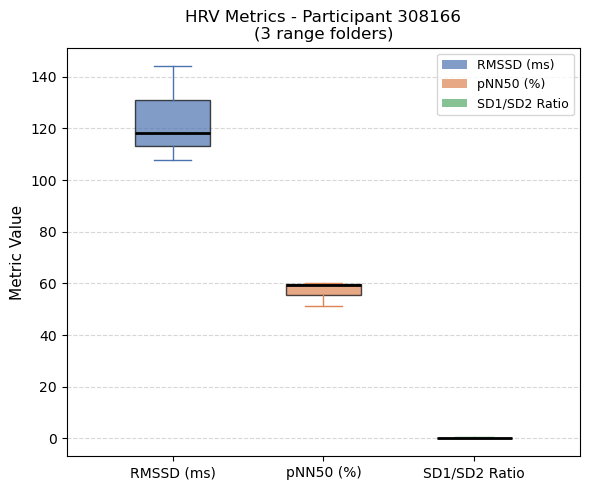

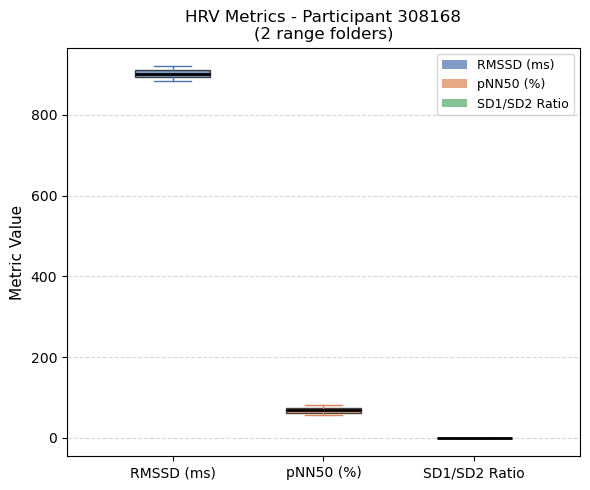

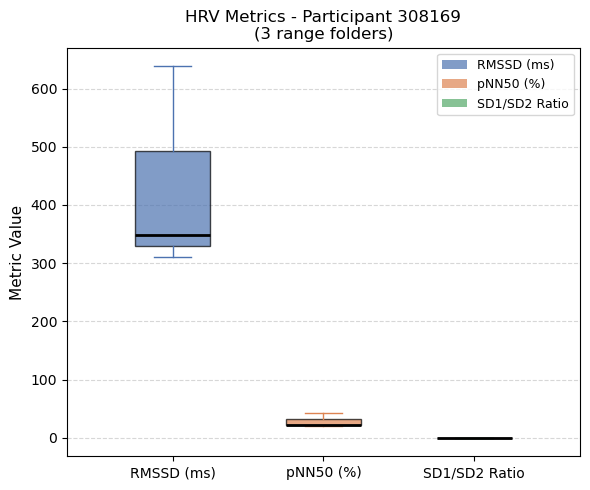

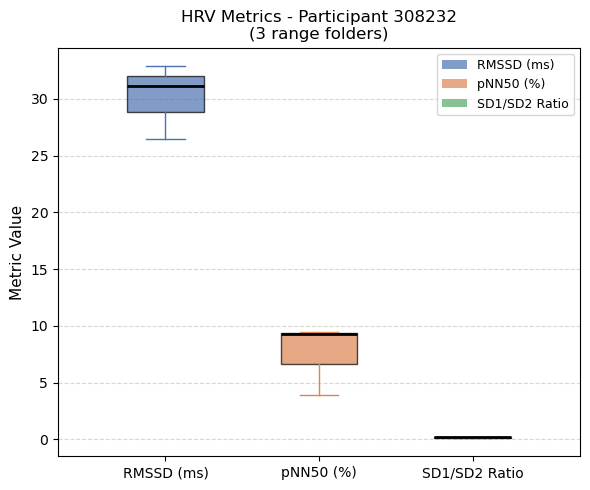

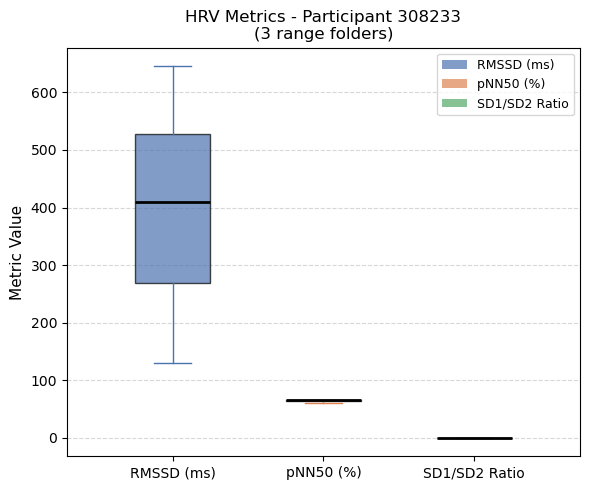

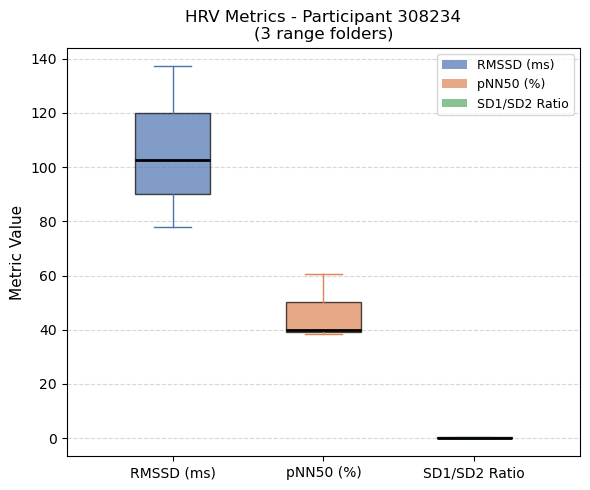

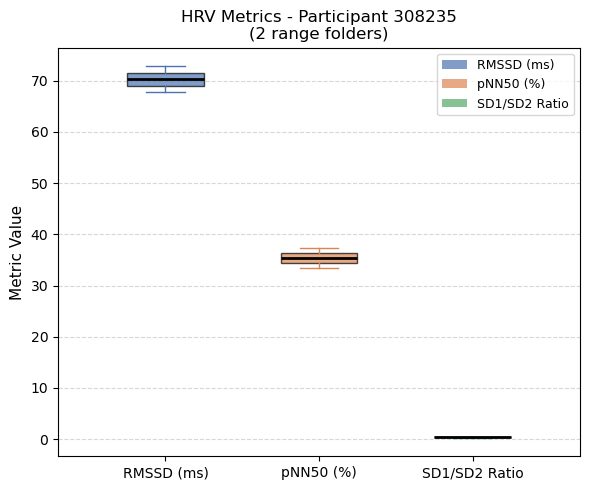

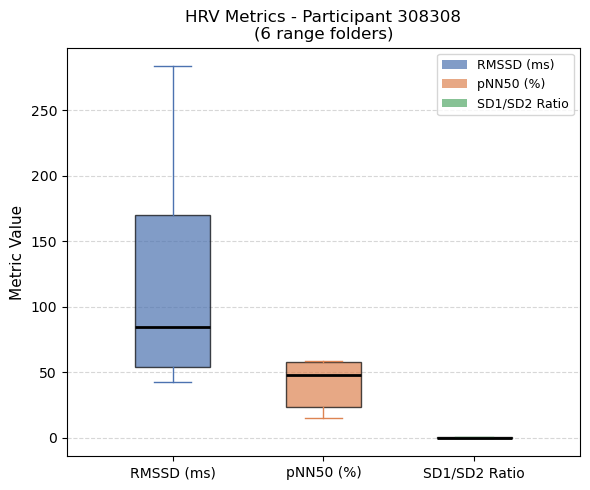

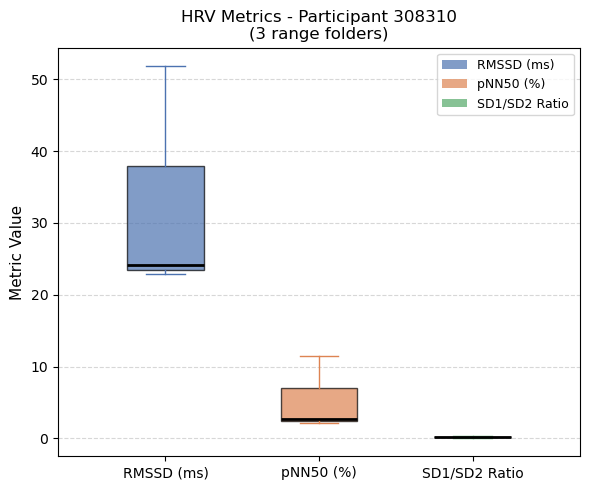

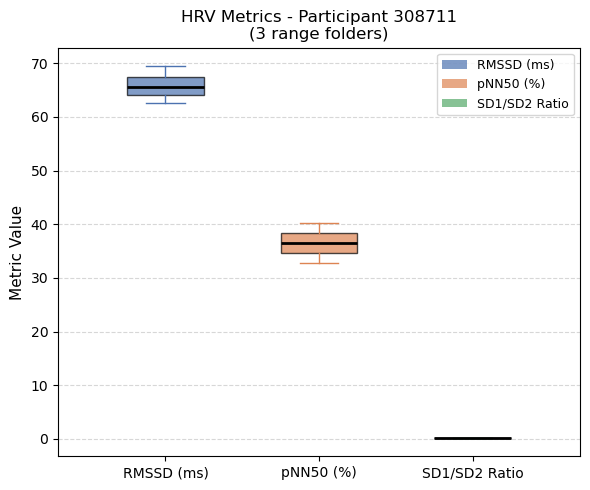

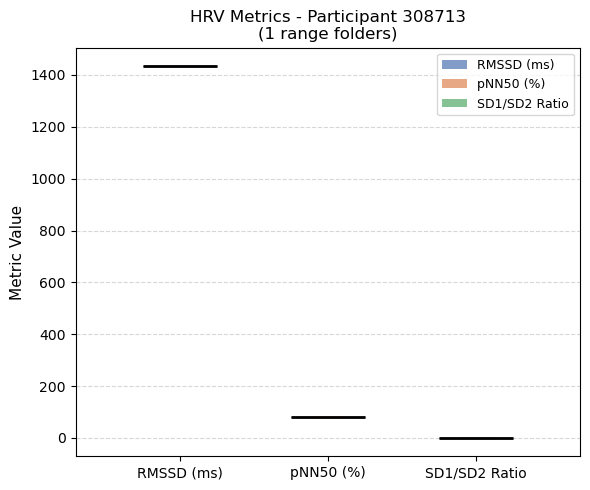

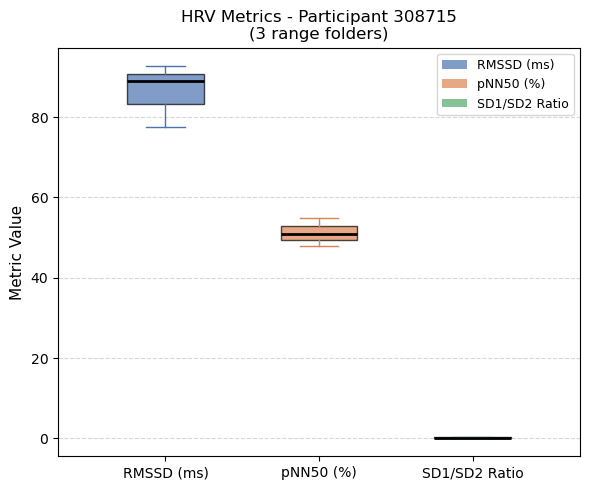

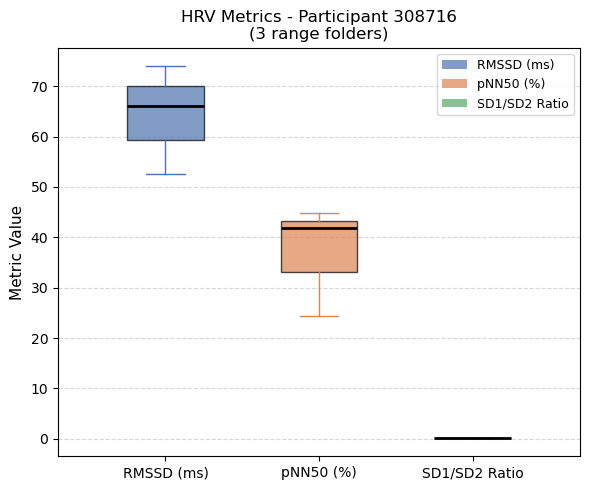

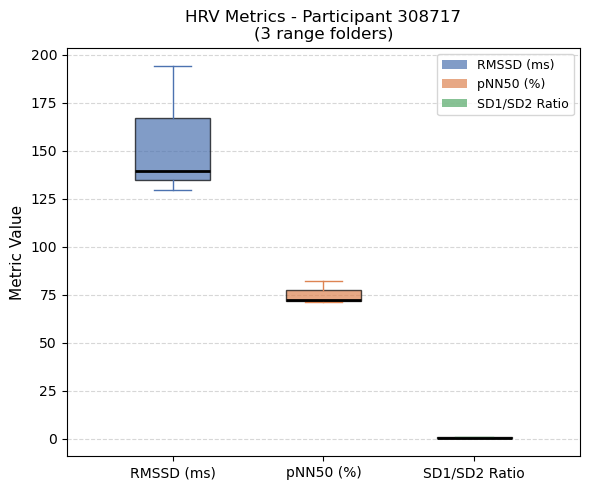

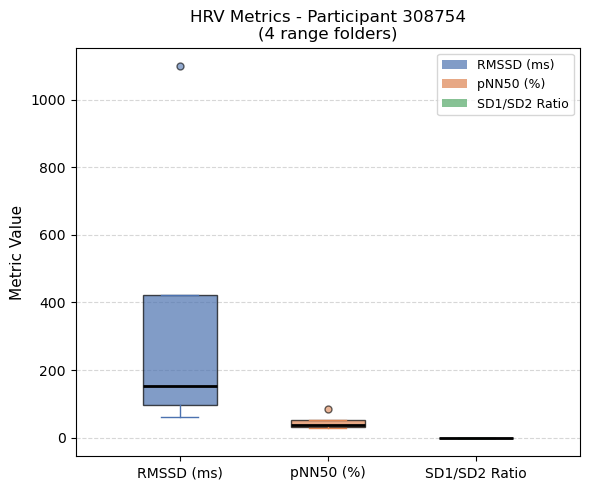

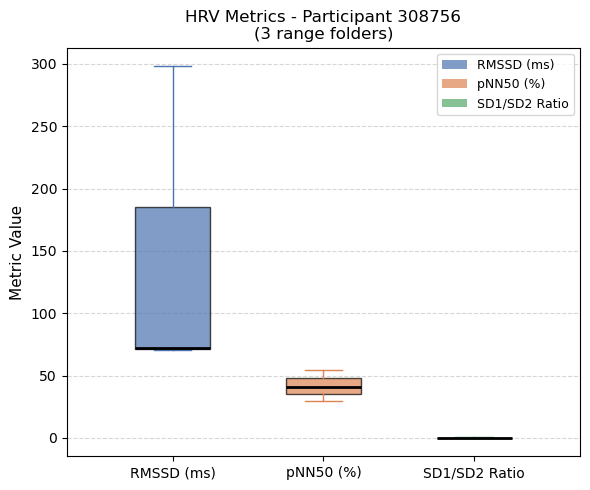

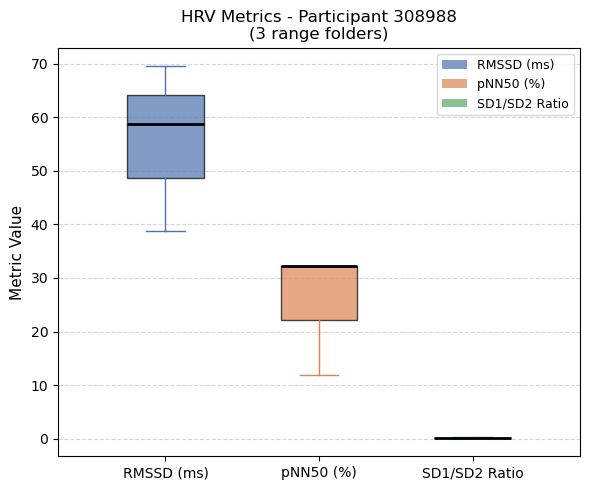

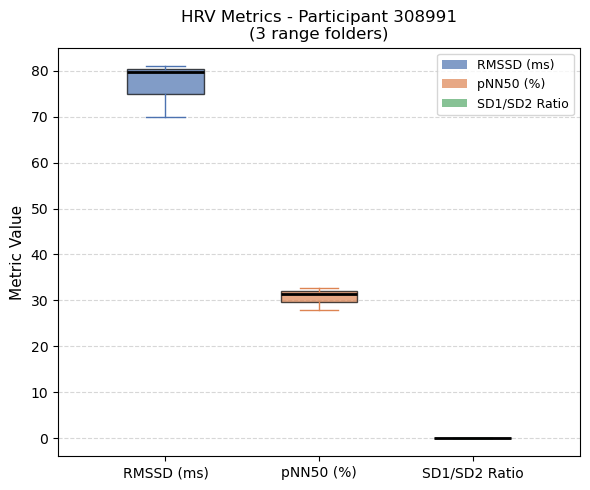

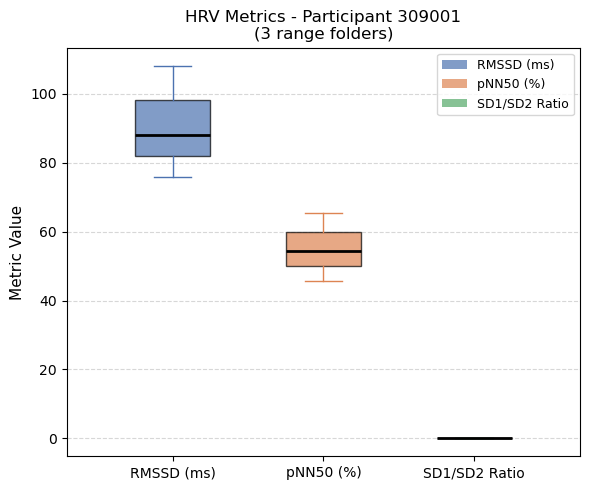

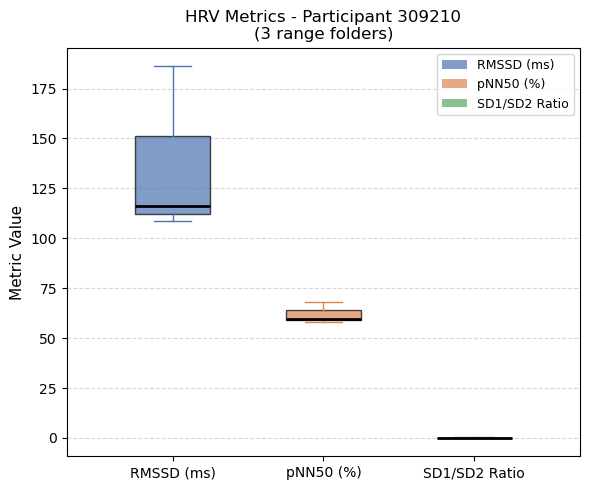

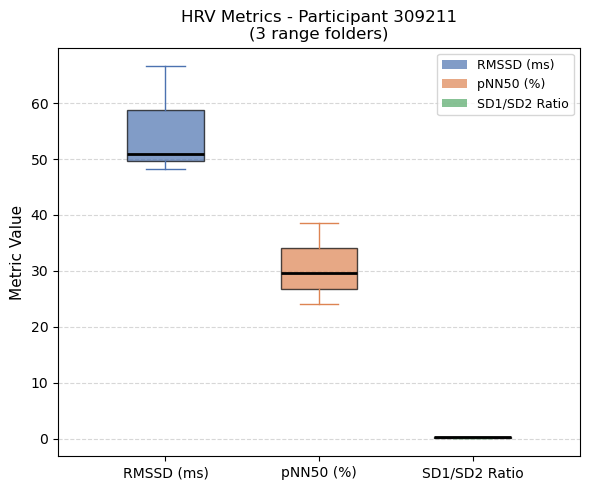

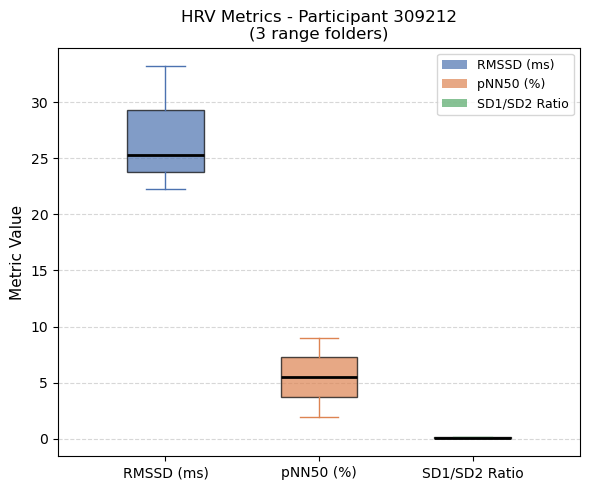

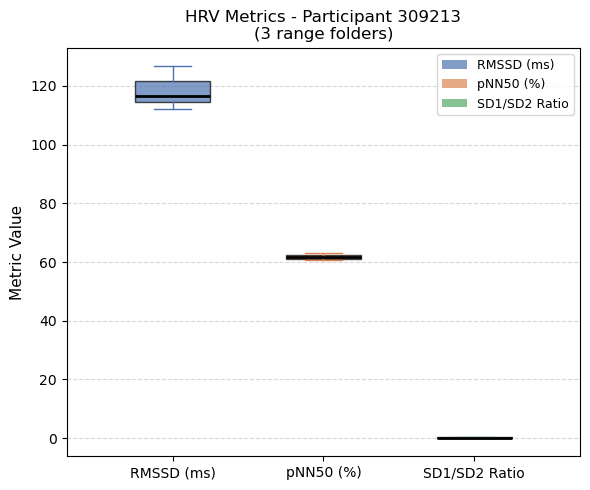

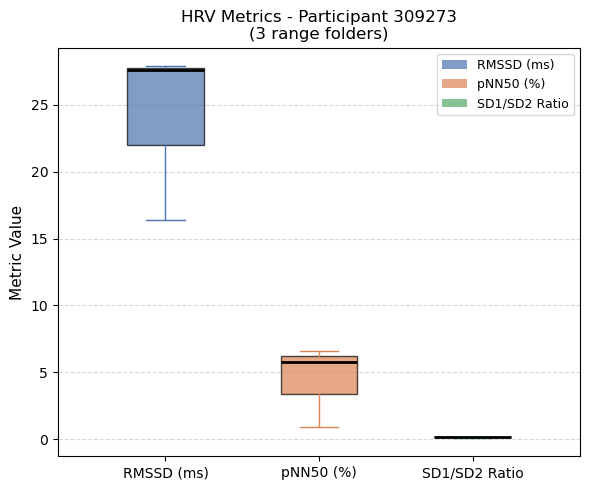

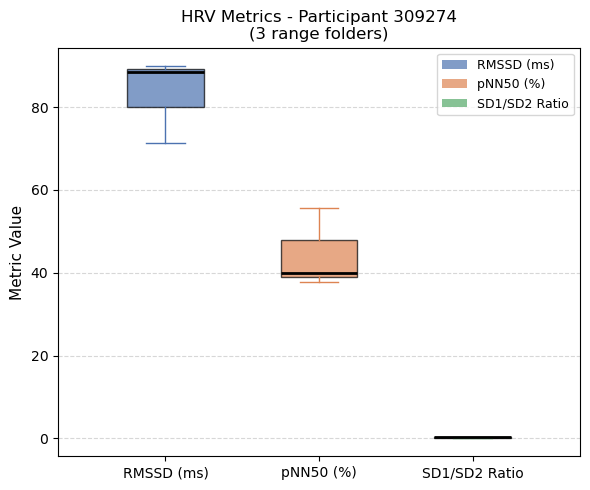

In [ ]:
def run_all_participants(base_folder, sampling_rate=256):

    all_records = []

    range_folders = sorted([
        os.path.join(base_folder, f)
        for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f))
    ])
    print(f"[INFO] Found {len(range_folders)} range folders")

    for range_folder in range_folders:
        range_name = os.path.basename(range_folder)

        record_folders = [
            os.path.join(range_folder, f)
            for f in os.listdir(range_folder)
            if os.path.isdir(os.path.join(range_folder, f))
        ]

        for record_folder in record_folders:
            record_name = os.path.basename(record_folder)

            match = re.search(r'record_(\d+)', record_name)
            if not match:
                print(f"[SKIP] Could not parse record number from: {record_name}")
                continue
            participant_id = match.group(1)

            wav_file = os.path.join(record_folder, 'ECG_I.wav')
            if not os.path.exists(wav_file):
                print(f"[MISSING] {range_name}/{record_name} - no ECG_I.wav")
                continue

            print(f"[PROCESSING] Participant {participant_id} - {range_name}")

            try:
                if record_folder not in sys.path:
                    sys.path.insert(0, record_folder)
                import load_hx_data
                load_hx_data.set_device_model('hx')

                # Load ECG
                ecg_data  = load_hx_data.load_wave(wav_file)
                ecg       = pd.DataFrame(ecg_data, columns=['time', 'ECG'])
                ecg_numpy = ecg['ECG'].to_numpy()

                # Clean and detect peaks
                ecg_cleaned    = nk.ecg_clean(ecg_numpy, sampling_rate=sampling_rate)
                peaks_df, info = nk.ecg_peaks(
                    ecg_cleaned,
                    sampling_rate=sampling_rate,
                    correct_artifacts=True,
                    show=False
                )

                # Extract RR intervals from peak sample indices
                peak_samples = np.array(info['ECG_R_Peaks'], dtype=int)
                rr_raw       = np.diff(peak_samples) / sampling_rate * 1000

                # RR filtering - physiological window
                physio_mask = (rr_raw >= 300) & (rr_raw <= 2000)

                # RR filtering - rolling median
                rr_series   = pd.Series(rr_raw)
                rolling_med = rr_series.rolling(window=10, center=True, min_periods=3).median().to_numpy()
                deviation   = np.abs(rr_raw - rolling_med) / rolling_med
                median_mask = np.where(np.isnan(rolling_med), True, deviation < 0.20).astype(bool)

                clean_mask = physio_mask & median_mask
                rr_clean   = rr_raw[clean_mask]

                if len(rr_clean) < 20:
                    print(f"[SKIP] {range_name}/{record_name} - too few clean RR intervals ({len(rr_clean)})")
                    continue

                # Kubios correction - returns corrected RR intervals
                rr_corrected, artifacts, _ = nk.intervals_process(
                    rr_clean,
                    intervaltype="RR",
                    artifact_method="Kubios",
                    artifact_threshold=0.25
                )

                # Convert RR intervals back to peak indices for neurokit HRV functions
                peaks_corrected = nk.intervals_to_peaks(rr_corrected)

                # Compute HRV metrics using peak indices
                hrv_time      = nk.hrv_time(peaks_corrected, sampling_rate=sampling_rate, show=False)
                hrv_nonlinear = nk.hrv_nonlinear(peaks_corrected, sampling_rate=sampling_rate, show=False)

                rmssd  = float(hrv_time['HRV_RMSSD'].values[0])
                pnn50  = float(hrv_time['HRV_pNN50'].values[0])
                sd1    = float(hrv_nonlinear['HRV_SD1'].values[0])
                sd2    = float(hrv_nonlinear['HRV_SD2'].values[0])
                sd1sd2 = sd1 / sd2 if sd2 != 0 else np.nan

                all_records.append({
                    'participant_id' : participant_id,
                    'range_folder'   : range_name,
                    'record_folder'  : record_name,
                    'RMSSD'          : rmssd,
                    'pNN50'          : pnn50,
                    'SD1_SD2_ratio'  : sd1sd2
                })

                print(f"  RMSSD={rmssd:.1f}  pNN50={pnn50:.1f}  SD1/SD2={sd1sd2:.3f}")

            except Exception as e:
                print(f"[ERROR] {range_name}/{record_name} - {e}")
                continue

    if not all_records:
        print("[WARN] No data collected.")
        return pd.DataFrame()

    df = pd.DataFrame(all_records)

    out_csv = os.path.join(base_folder, 'hrv_metrics_all_participants.csv')
    df.to_csv(out_csv, index=False)
    print(f"\n[SAVED] Metrics CSV: {out_csv}")
    print(df.to_string(index=False))

    plot_grouped_boxplots(df, base_folder)

    return df


def plot_grouped_boxplots(df, base_folder):
    """
    One separate figure per participant.
    Each figure has 3 boxes side by side: RMSSD, pNN50, SD1/SD2 ratio.
    Each box shows spread across that participant's range folders.
    """

    participants = sorted(df['participant_id'].unique())
    metrics      = ['RMSSD', 'pNN50', 'SD1_SD2_ratio']
    labels       = ['RMSSD (ms)', 'pNN50 (%)', 'SD1/SD2 Ratio']
    colors       = ['#4C72B0', '#DD8452', '#55A868']
    positions    = [1, 2, 3]

    for pid in participants:
        pid_df = df[df['participant_id'] == pid]
        data   = [pid_df[m].dropna().tolist() for m in metrics]

        fig, ax = plt.subplots(figsize=(6, 5))
        box_handles = []

        for i, (metric, label, color, pos) in enumerate(zip(metrics, labels, colors, positions)):
            values = pid_df[metric].dropna().tolist()

            bp = ax.boxplot(
                [values],
                positions=[pos],
                widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=color),
                capprops=dict(color=color),
                flierprops=dict(marker='o', markerfacecolor=color, markersize=5, alpha=0.6),
                manage_ticks=False
            )
            box_handles.append(mpatches.Patch(facecolor=color, alpha=0.7, label=label))

        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel('Metric Value', fontsize=11)
        ax.set_title(f'HRV Metrics - Participant {pid}\n({len(pid_df)} range folders)', fontsize=12)
        ax.legend(handles=box_handles, fontsize=9, loc='upper right')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.set_xlim(0.3, 3.7)

        plt.tight_layout()

        out_fig = os.path.join(base_folder, f'hrv_boxplot_participant_{pid}.png')
        plt.show()


# Run
base_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
df = run_all_participants(base_folder, sampling_rate=256)

[INFO] Found 82 range folders
[PROCESSING] Participant 308166 - range_3324350-datatype_4096-1006
  RMSSD=107.8  pNN50=51.4  SD1/SD2=0.296
[PROCESSING] Participant 308166 - range_3324351-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=144.0  pNN50=60.0  SD1/SD2=0.410
[PROCESSING] Participant 308166 - range_3324354-datatype_4096-1006
  RMSSD=118.3  pNN50=59.5  SD1/SD2=0.292
[PROCESSING] Participant 308168 - range_3324355-datatype_4096-1006
  RMSSD=920.5  pNN50=55.6  SD1/SD2=0.308
[PROCESSING] Participant 308168 - range_3324409-datatype_4096-1006
  RMSSD=884.7  pNN50=80.6  SD1/SD2=0.431
[PROCESSING] Participant 308168 - range_3324410-datatype_4096-1006
[SKIP] range_3324410-datatype_4096-1006/record_308168 - too few clean RR intervals (17)


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the m

[PROCESSING] Participant 308169 - range_3324420-datatype_4096-1006
  RMSSD=348.1  pNN50=22.8  SD1/SD2=0.566
[PROCESSING] Participant 308169 - range_3324421-datatype_4096-1006
  RMSSD=638.2  pNN50=42.1  SD1/SD2=0.270
[PROCESSING] Participant 308169 - range_3324422-datatype_4096-1006


...

  RMSSD=25.3  pNN50=5.5  SD1/SD2=0.092
[PROCESSING] Participant 309212 - range_3333668-datatype_4096-1006
  RMSSD=22.2  pNN50=1.9  SD1/SD2=0.083
[PROCESSING] Participant 309212 - range_3333669-datatype_4096-1006
  RMSSD=33.2  pNN50=9.0  SD1/SD2=0.124
[PROCESSING] Participant 309213 - range_3333675-datatype_4096-1006
  RMSSD=116.7  pNN50=62.9  SD1/SD2=0.402
[PROCESSING] Participant 309213 - range_3333676-datatype_4096-1006
  RMSSD=112.1  pNN50=60.6  SD1/SD2=0.147
[PROCESSING] Participant 309213 - range_3333677-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=126.7  pNN50=61.8  SD1/SD2=0.193
[PROCESSING] Participant 309273 - range_3334287-datatype_4096-1006
  RMSSD=27.9  pNN50=6.6  SD1/SD2=0.196
[PROCESSING] Participant 309273 - range_3334288-datatype_4096-1006
  RMSSD=27.6  pNN50=5.8  SD1/SD2=0.199
[PROCESSING] Participant 309273 - range_3334289-datatype_4096-1006
  RMSSD=16.4  pNN50=0.9  SD1/SD2=0.124
[PROCESSING] Participant 309274 - range_3334294-datatype_4096-1006
  RMSSD=89.8  pNN50=55.6  SD1/SD2=0.339
[PROCESSING] Participant 309274 - range_3334295-datatype_4096-1006
  RMSSD=88.5  pNN50=40.0  SD1/SD2=0.243
[PROCESSING] Participant 309274 - range_3334296-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=71.4  pNN50=37.9  SD1/SD2=0.180

[SAVED] Metrics CSV: C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\hrv_metrics_all_participants.csv
participant_id                     range_folder record_folder       RMSSD     pNN50  SD1_SD2_ratio
        308166 range_3324350-datatype_4096-1006 record_308166  107.825477 51.401869       0.295719
        308166 range_3324351-datatype_4096-1006 record_308166  144.048762 60.000000       0.409918
        308166 range_3324354-datatype_4096-1006 record_308166  118.274289 59.477124       0.292320
        308168 range_3324355-datatype_4096-1006 record_308168  920.549142 55.555556       0.307633
        308168 range_3324409-datatype_4096-1006 record_308168  884.736737 80.645161       0.431195
        308169 range_3324420-datatype_4096-1006 record_308169  348.134546 22.772277       0.566443
        308169 range_3324421-datatype_4096-1006 record_308169  638.228680 42.105263       0.269608
        308169 range_3324422-datatype_4096-1006 record_308169  

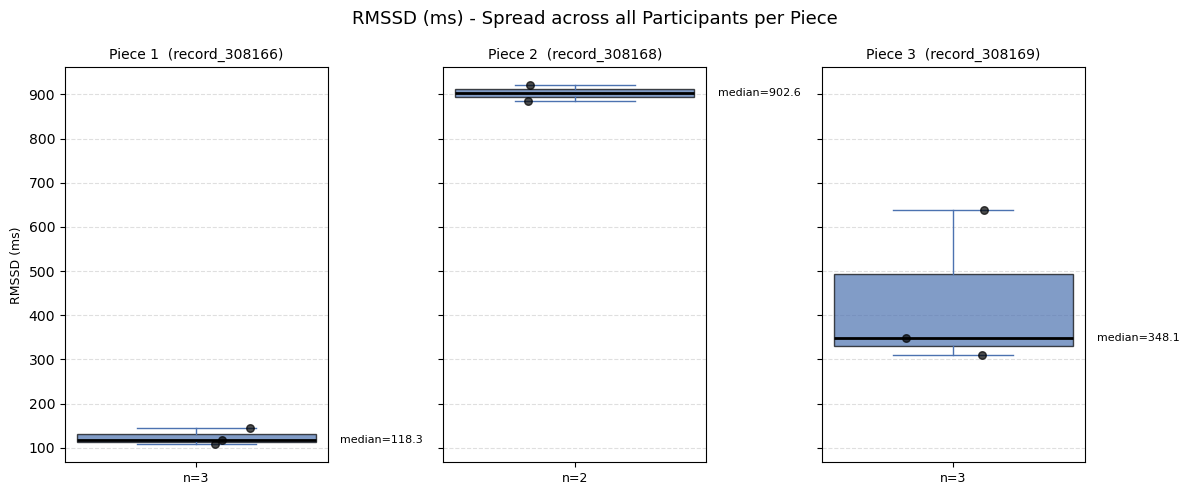

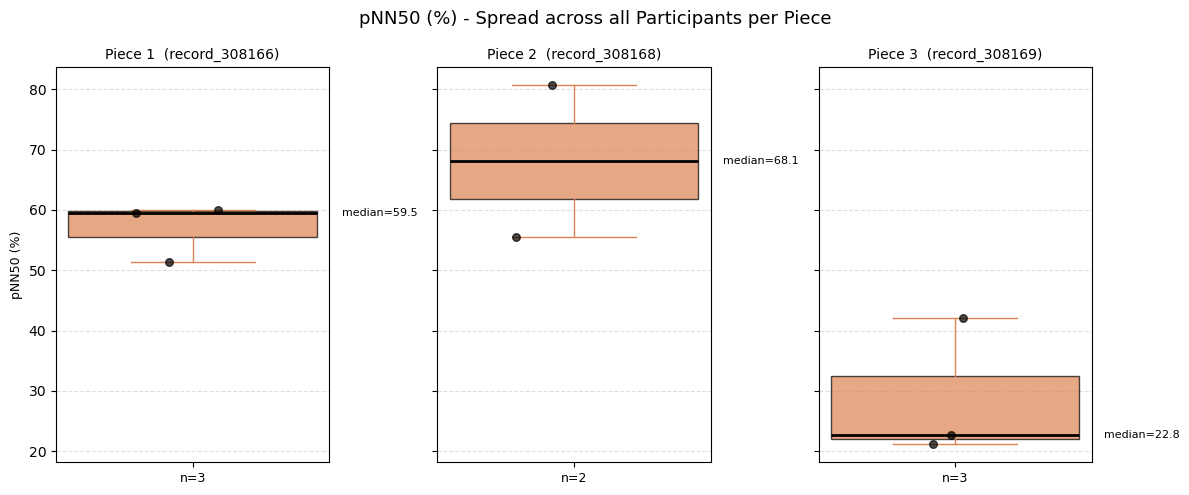

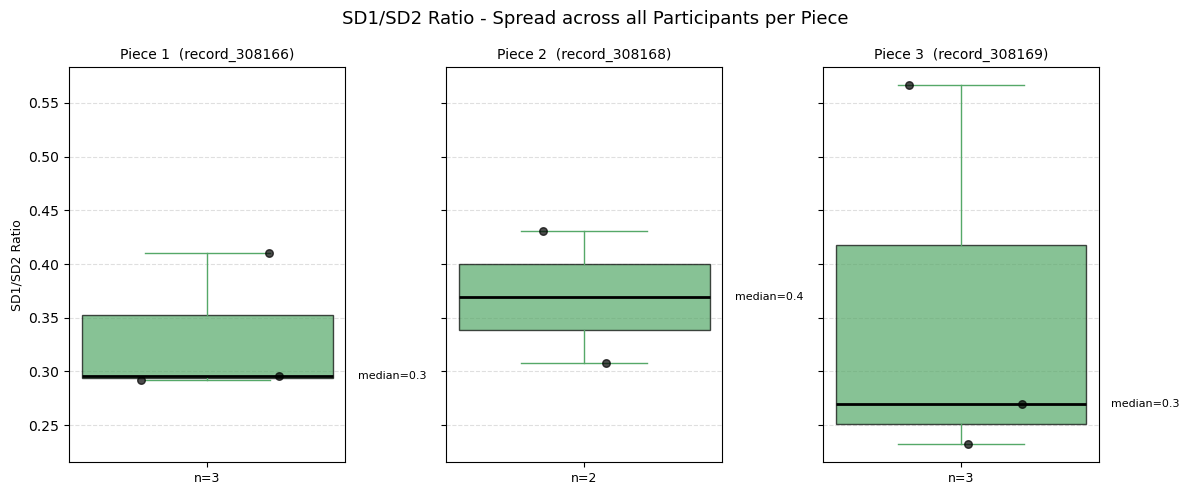

In [ ]:
import sys
import os
import re
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def run_all_participants(base_folder, sampling_rate=256):

    all_records = []

    range_folders = sorted([
        os.path.join(base_folder, f)
        for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f))
    ])
    print(f"[INFO] Found {len(range_folders)} range folders")

    for range_folder in range_folders:
        range_name = os.path.basename(range_folder)

        record_folders = [
            os.path.join(range_folder, f)
            for f in os.listdir(range_folder)
            if os.path.isdir(os.path.join(range_folder, f))
        ]

        for record_folder in record_folders:
            record_name = os.path.basename(record_folder)

            match = re.search(r'record_(\d+)', record_name)
            if not match:
                print(f"[SKIP] Could not parse record number from: {record_name}")
                continue
            participant_id = match.group(1)

            wav_file = os.path.join(record_folder, 'ECG_I.wav')
            if not os.path.exists(wav_file):
                print(f"[MISSING] {range_name}/{record_name} - no ECG_I.wav")
                continue

            print(f"[PROCESSING] Participant {participant_id} - {range_name}")

            try:
                if record_folder not in sys.path:
                    sys.path.insert(0, record_folder)
                import load_hx_data
                load_hx_data.set_device_model('hx')

                # Load ECG
                ecg_data  = load_hx_data.load_wave(wav_file)
                ecg       = pd.DataFrame(ecg_data, columns=['time', 'ECG'])
                ecg_numpy = ecg['ECG'].to_numpy()

                # Clean and detect peaks
                ecg_cleaned    = nk.ecg_clean(ecg_numpy, sampling_rate=sampling_rate)
                peaks_df, info = nk.ecg_peaks(
                    ecg_cleaned,
                    sampling_rate=sampling_rate,
                    correct_artifacts=True,
                    show=False
                )

                # Extract RR intervals from peak sample indices
                peak_samples = np.array(info['ECG_R_Peaks'], dtype=int)
                rr_raw       = np.diff(peak_samples) / sampling_rate * 1000

                # RR filtering - physiological window
                physio_mask = (rr_raw >= 300) & (rr_raw <= 2000)

                # RR filtering - rolling median
                rr_series   = pd.Series(rr_raw)
                rolling_med = rr_series.rolling(window=10, center=True, min_periods=3).median().to_numpy()
                deviation   = np.abs(rr_raw - rolling_med) / rolling_med
                median_mask = np.where(np.isnan(rolling_med), True, deviation < 0.20).astype(bool)

                clean_mask = physio_mask & median_mask
                rr_clean   = rr_raw[clean_mask]

                if len(rr_clean) < 20:
                    print(f"[SKIP] {range_name}/{record_name} - too few clean RR intervals ({len(rr_clean)})")
                    continue

                # Kubios correction - returns corrected RR intervals
                rr_corrected, artifacts, _ = nk.intervals_process(
                    rr_clean,
                    intervaltype="RR",
                    artifact_method="Kubios",
                    artifact_threshold=0.25
                )

                # Convert RR intervals back to peak indices for neurokit HRV functions
                peaks_corrected = nk.intervals_to_peaks(rr_corrected)

                # Compute HRV time domain metrics
                hrv_time      = nk.hrv_time(peaks_corrected, sampling_rate=sampling_rate, show=False)

                # Compute HRV nonlinear metrics - SD1, SD2 and SD1/SD2 ratio come directly from here
                hrv_nonlinear = nk.hrv_nonlinear(peaks_corrected, sampling_rate=sampling_rate, show=False)

                rmssd  = float(hrv_time['HRV_RMSSD'].values[0])
                pnn50  = float(hrv_time['HRV_pNN50'].values[0])
                # HRV_SD1SD2 is the SD1/SD2 ratio computed directly by hrv_nonlinear
                sd1sd2 = float(hrv_nonlinear['HRV_SD1SD2'].values[0])

                all_records.append({
                    'participant_id' : participant_id,
                    'range_folder'   : range_name,
                    'record_folder'  : record_name,
                    'RMSSD'          : rmssd,
                    'pNN50'          : pnn50,
                    'SD1_SD2_ratio'  : sd1sd2
                })

                print(f"  RMSSD={rmssd:.1f}  pNN50={pnn50:.1f}  SD1/SD2={sd1sd2:.3f}")

            except Exception as e:
                print(f"[ERROR] {range_name}/{record_name} - {e}")
                continue

    if not all_records:
        print("[WARN] No data collected.")
        return pd.DataFrame()

    df = pd.DataFrame(all_records)

    out_csv = os.path.join(base_folder, 'hrv_metrics_all_participants.csv')
    df.to_csv(out_csv, index=False)
    print(f"\n[SAVED] Metrics CSV: {out_csv}")
    print(df.to_string(index=False))

    plot_metric_across_participants(df, base_folder)

    return df


def plot_metric_across_participants(df, base_folder):
    """
    3 main figures - one per metric (RMSSD, pNN50, SD1SD2).
    Each figure has 1 subplot with 3 boxes - one box per piece.
    Each box shows the spread of all participant values for that piece.
    """

    record_folders = sorted(df['record_folder'].unique())[:3]
    metrics        = ['RMSSD', 'pNN50', 'SD1_SD2_ratio']
    labels         = ['RMSSD (ms)', 'pNN50 (%)', 'SD1/SD2 Ratio']
    colors         = ['#4C72B0', '#DD8452', '#55A868']

    for metric, label, color in zip(metrics, labels, colors):

        fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
        fig.suptitle(f'{label} - Spread across all Participants per Piece', fontsize=13)

        for i, (ax, record) in enumerate(zip(axes, record_folders)):

            # All participant values for this piece
            values = df[df['record_folder'] == record][metric].dropna().tolist()

            if not values:
                ax.set_title(f'Piece {i+1}  no data')
                continue

            ax.boxplot(
                [values],
                positions=[1],
                widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=color),
                capprops=dict(color=color),
                flierprops=dict(marker='o', markerfacecolor=color,
                                markersize=6, alpha=0.7),
                manage_ticks=False
            )

            # Overlay individual participant points
            x_jitter = np.random.uniform(0.85, 1.15, size=len(values))
            ax.scatter(x_jitter, values, color='black', s=30,
                       zorder=5, alpha=0.7)

            # Annotate stats
            med = float(np.median(values))
            ax.text(1.3, med, f'median={med:.1f}',
                    va='center', fontsize=8, color='black')

            ax.set_title(f'Piece {i+1}  ({record})', fontsize=10)
            ax.set_ylabel(label if i == 0 else '', fontsize=9)
            ax.set_xticks([1])
            ax.set_xticklabels([f'n={len(values)}'], fontsize=9)
            ax.grid(axis='y', linestyle='--', alpha=0.4)

        plt.tight_layout()
        out_fig = os.path.join(base_folder, f'hrv_{metric}_pieces.png')
        plt.show()


# Run
base_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
df = run_all_participants(base_folder, sampling_rate=256)

[INFO] Looking in: C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\range_3324350-datatype_4096-1006
[INFO] Files found: ['activity.csv', 'breathing_rate.csv', 'breathing_rate_quality.csv', 'cadence.csv', 'device_position.csv', 'energy_mifflin_keytel.csv', 'expiration.csv', 'heart_rate.csv', 'heart_rate_quality.csv', 'info.json', 'inspiration.csv', 'minute_ventilation_adjusted.csv', 'minute_ventilation_raw.csv', 'NN_interval.csv', 'record_308166', 'RR_interval.csv', 'RR_interval_quality.csv', 'sleep_position.csv', 'statistics.csv', 'tidal_volume_adjusted.csv', 'tidal_volume_raw.csv']
[INFO] heart_rate.csv found
[INFO] breathing_rate.csv found


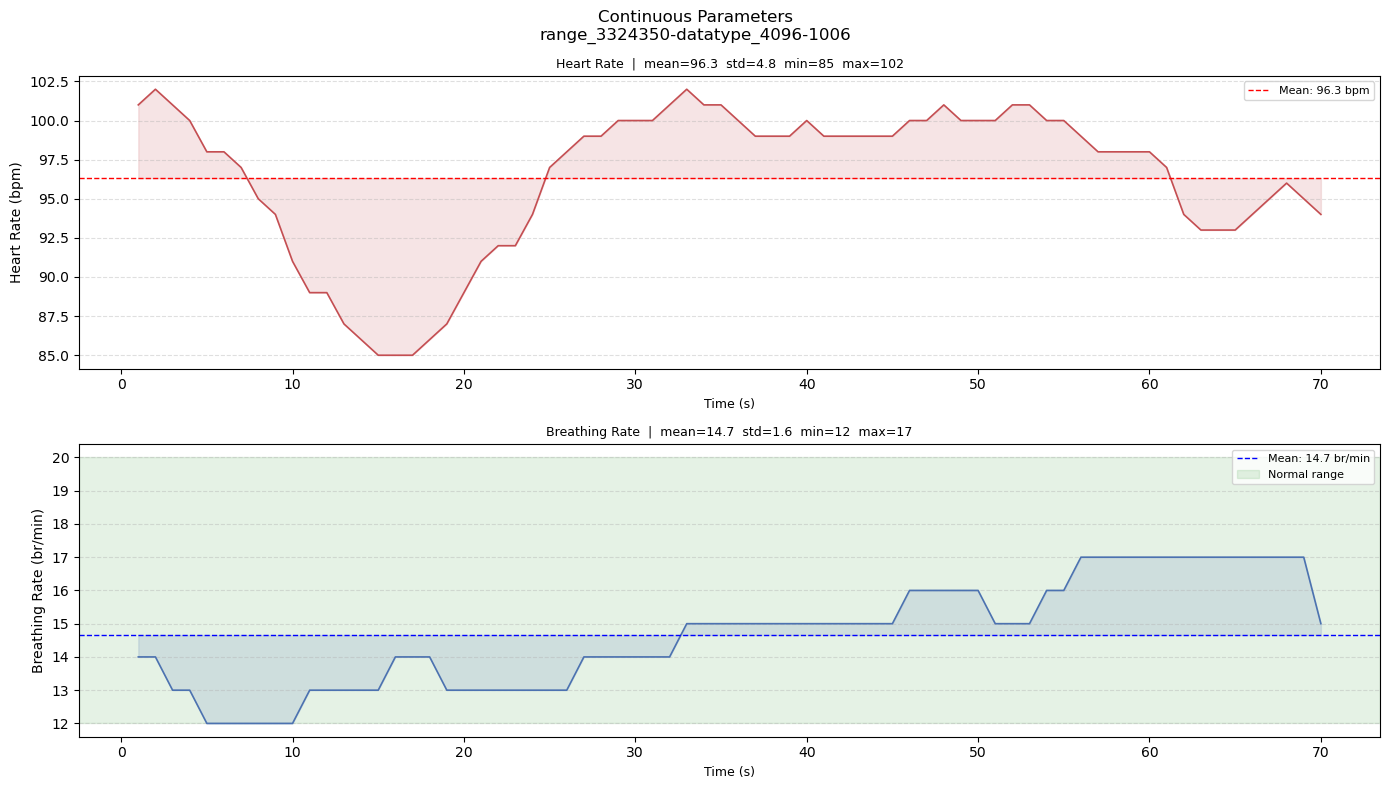

{'mean_hr': 96.31, 'std_hr': 4.83, 'mean_br': 14.66, 'std_br': 1.61}


In [ ]:
import sys
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_continuous_parameters(folder, sampling_rate_ecg=256):

    # Step 1: Load heart rate CSV - no load_hx_data needed for CSV files
    hr_csv  = os.path.join(folder, 'heart_rate.csv')
    br_csv  = os.path.join(folder, 'breathing_rate.csv')
    vol_csv = os.path.join(folder, 'inspired_breathing_volume.csv')

    print(f"[INFO] Looking in: {folder}")
    print(f"[INFO] Files found: {os.listdir(folder)}")

    if not os.path.exists(hr_csv):
        raise FileNotFoundError(f"heart_rate.csv not found in {folder}")
    if not os.path.exists(br_csv):
        raise FileNotFoundError(f"breathing_rate.csv not found in {folder}")

    print(f"[INFO] heart_rate.csv found")
    print(f"[INFO] breathing_rate.csv found")

    hr_df  = pd.read_csv(hr_csv)
    br_df  = pd.read_csv(br_csv)

    hr_time = hr_df.iloc[:, 0].to_numpy()
    hr_vals = hr_df.iloc[:, 1].dropna().to_numpy()
    br_time = br_df.iloc[:, 0].to_numpy()
    br_vals = br_df.iloc[:, 1].dropna().to_numpy()

    # Clean physiologically implausible values
    hr_mask = (hr_vals >= 30) & (hr_vals <= 220)
    br_mask = (br_vals >= 2)  & (br_vals <= 60)
    hr_time, hr_vals = hr_time[:len(hr_vals)][hr_mask], hr_vals[hr_mask]
    br_time, br_vals = br_time[:len(br_vals)][br_mask], br_vals[br_mask]

    # Load volume if available
    vol_time = vol_vals = None
    if os.path.exists(vol_csv):
        vol_df   = pd.read_csv(vol_csv)
        vol_time = vol_df.iloc[:, 0].to_numpy()
        vol_vals = vol_df.iloc[:, 1].dropna().to_numpy()
        vol_mask = (vol_vals > 0) & (vol_vals < 5000)
        vol_time = vol_time[:len(vol_vals)][vol_mask]
        vol_vals = vol_vals[vol_mask]

    n_plots = 3 if vol_vals is not None else 2
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4 * n_plots), sharex=False)
    fig.suptitle(f'Continuous Parameters\n{os.path.basename(folder)}', fontsize=12)

    # Plot 1 - Heart rate
    axes[0].plot(hr_time, hr_vals, color='#C44E52', linewidth=1.2)
    axes[0].axhline(np.mean(hr_vals), color='red', linestyle='--',
                    linewidth=1, label=f'Mean: {np.mean(hr_vals):.1f} bpm')
    axes[0].fill_between(hr_time, hr_vals, np.mean(hr_vals),
                         alpha=0.15, color='#C44E52')
    axes[0].set_ylabel('Heart Rate (bpm)', fontsize=10)
    axes[0].set_title(f'Heart Rate  |  mean={np.mean(hr_vals):.1f}  '
                      f'std={np.std(hr_vals, ddof=1):.1f}  '
                      f'min={hr_vals.min():.0f}  max={hr_vals.max():.0f}', fontsize=9)
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 2 - Breathing rate
    axes[1].plot(br_time, br_vals, color='#4C72B0', linewidth=1.2)
    axes[1].axhline(np.mean(br_vals), color='blue', linestyle='--',
                    linewidth=1, label=f'Mean: {np.mean(br_vals):.1f} br/min')
    axes[1].axhspan(12, 20, alpha=0.1, color='green', label='Normal range')
    axes[1].fill_between(br_time, br_vals, np.mean(br_vals),
                         alpha=0.15, color='#4C72B0')
    axes[1].set_ylabel('Breathing Rate (br/min)', fontsize=10)
    axes[1].set_title(f'Breathing Rate  |  mean={np.mean(br_vals):.1f}  '
                      f'std={np.std(br_vals, ddof=1):.1f}  '
                      f'min={br_vals.min():.0f}  max={br_vals.max():.0f}', fontsize=9)
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 3 - Volume if available
    if vol_vals is not None:
        axes[2].plot(vol_time, vol_vals, color='#55A868', linewidth=1.2)
        axes[2].axhline(np.mean(vol_vals), color='green', linestyle='--',
                        linewidth=1, label=f'Mean: {np.mean(vol_vals):.0f} ml')
        axes[2].fill_between(vol_time, vol_vals, np.mean(vol_vals),
                             alpha=0.15, color='#55A868')
        axes[2].set_ylabel('Inspired Volume (ml)', fontsize=10)
        axes[2].set_title(f'Inspired Volume  |  mean={np.mean(vol_vals):.0f}  '
                          f'std={np.std(vol_vals, ddof=1):.0f}  '
                          f'min={vol_vals.min():.0f}  max={vol_vals.max():.0f}', fontsize=9)
        axes[2].legend(fontsize=8)
        axes[2].grid(axis='y', linestyle='--', alpha=0.4)

    for ax in axes:
        ax.set_xlabel('Time (s)', fontsize=9)

    plt.tight_layout()
    plt.show()

    return {
        'mean_hr'  : round(float(np.mean(hr_vals)), 2),
        'std_hr'   : round(float(np.std(hr_vals, ddof=1)), 2),
        'mean_br'  : round(float(np.mean(br_vals)), 2),
        'std_br'   : round(float(np.std(br_vals, ddof=1)), 2),
    }


def run_all(base_folder):
    results = []
    for range_f in sorted(os.listdir(base_folder)):
        range_path = os.path.join(base_folder, range_f)
        if not os.path.isdir(range_path):
            continue
        for record_f in sorted(os.listdir(range_path)):
            record_path = os.path.join(range_path, record_f)
            if not os.path.isdir(record_path):
                continue
            match = re.search(r'record_(\d+)', record_f)
            if not match:
                continue
            # Find subfolder with same name
            csv_folder = os.path.join(record_path, record_f)
            if not os.path.isdir(csv_folder):
                csv_folder = record_path
            try:
                r = plot_continuous_parameters(csv_folder)
                r.update({'participant_id': match.group(1), 'range_folder': range_f})
                results.append(r)
            except Exception as e:
                print(f"[ERROR] {range_f}/{record_f} - {e}")

    df = pd.DataFrame(results)
    df.to_csv(os.path.join(base_folder, 'continuous_parameters_summary.csv'), index=False)
    print(f"[SAVED] continuous_parameters_summary.csv")
    return df


if __name__ == '__main__':
    # Test single folder first
    folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\range_3324350-datatype_4096-1006'
    results = plot_continuous_parameters(folder)
    print(results)

    # Run all folders
    # base_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
    # df = run_all(base_folder)

[INFO] Found 82 range folders
[PROCESSING] Participant 308166 - range_3324350-datatype_4096-1006
  RMSSD=107.8  pNN50=51.4  SD1/SD2=0.296
[PROCESSING] Participant 308166 - range_3324351-datatype_4096-1006
  RMSSD=144.0  pNN50=60.0  SD1/SD2=0.410
[PROCESSING] Participant 308166 - range_3324354-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=118.3  pNN50=59.5  SD1/SD2=0.292
[PROCESSING] Participant 308168 - range_3324355-datatype_4096-1006
  RMSSD=920.5  pNN50=55.6  SD1/SD2=0.308
[PROCESSING] Participant 308168 - range_3324409-datatype_4096-1006
  RMSSD=884.7  pNN50=80.6  SD1/SD2=0.431
[PROCESSING] Participant 308168 - range_3324410-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the m

[SKIP] range_3324410-datatype_4096-1006/record_308168 - too few clean RR intervals (17)
[PROCESSING] Participant 308169 - range_3324420-datatype_4096-1006
  RMSSD=348.1  pNN50=22.8  SD1/SD2=0.566
[PROCESSING] Participant 308169 - range_3324421-datatype_4096-1006
  RMSSD=638.2  pNN50=42.1  SD1/SD2=0.270
[PROCESSING] Participant 308169 - range_3324422-datatype_4096-1006


...

  RMSSD=48.3  pNN50=24.1  SD1/SD2=0.163
[PROCESSING] Participant 309212 - range_3333667-datatype_4096-1006
  RMSSD=25.3  pNN50=5.5  SD1/SD2=0.092
[PROCESSING] Participant 309212 - range_3333668-datatype_4096-1006
  RMSSD=22.2  pNN50=1.9  SD1/SD2=0.083
[PROCESSING] Participant 309212 - range_3333669-datatype_4096-1006
  RMSSD=33.2  pNN50=9.0  SD1/SD2=0.124
[PROCESSING] Participant 309213 - range_3333675-datatype_4096-1006
  RMSSD=116.7  pNN50=62.9  SD1/SD2=0.402
[PROCESSING] Participant 309213 - range_3333676-datatype_4096-1006
  RMSSD=112.1  pNN50=60.6  SD1/SD2=0.147
[PROCESSING] Participant 309213 - range_3333677-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=126.7  pNN50=61.8  SD1/SD2=0.193
[PROCESSING] Participant 309273 - range_3334287-datatype_4096-1006
  RMSSD=27.9  pNN50=6.6  SD1/SD2=0.196
[PROCESSING] Participant 309273 - range_3334288-datatype_4096-1006
  RMSSD=27.6  pNN50=5.8  SD1/SD2=0.199
[PROCESSING] Participant 309273 - range_3334289-datatype_4096-1006
  RMSSD=16.4  pNN50=0.9  SD1/SD2=0.124
[PROCESSING] Participant 309274 - range_3334294-datatype_4096-1006
  RMSSD=89.8  pNN50=55.6  SD1/SD2=0.339
[PROCESSING] Participant 309274 - range_3334295-datatype_4096-1006
  RMSSD=88.5  pNN50=40.0  SD1/SD2=0.243
[PROCESSING] Participant 309274 - range_3334296-datatype_4096-1006


c:\Users\manognas\AppData\Local\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


  RMSSD=71.4  pNN50=37.9  SD1/SD2=0.180

[SAVED] Metrics CSV: C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\hrv_metrics_all_participants.csv
participant_id                     range_folder record_folder       RMSSD     pNN50  SD1_SD2_ratio
        308166 range_3324350-datatype_4096-1006 record_308166  107.825477 51.401869       0.295719
        308166 range_3324351-datatype_4096-1006 record_308166  144.048762 60.000000       0.409918
        308166 range_3324354-datatype_4096-1006 record_308166  118.274289 59.477124       0.292320
        308168 range_3324355-datatype_4096-1006 record_308168  920.549142 55.555556       0.307633
        308168 range_3324409-datatype_4096-1006 record_308168  884.736737 80.645161       0.431195
        308169 range_3324420-datatype_4096-1006 record_308169  348.134546 22.772277       0.566443
        308169 range_3324421-datatype_4096-1006 record_308169  638.228680 42.105263       0.269608
        308169 range_3324422-datatype_4096-1006 record_308169  

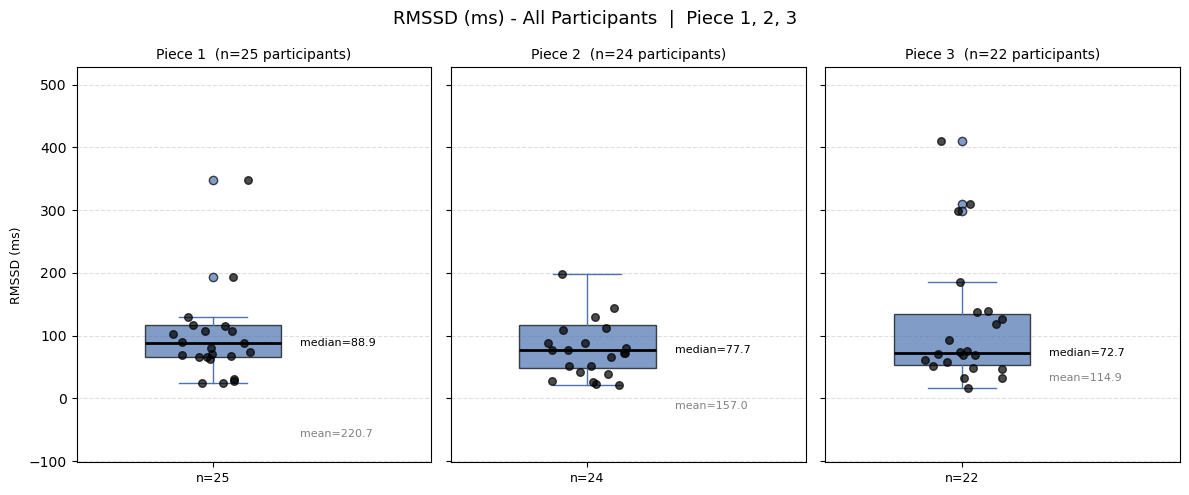

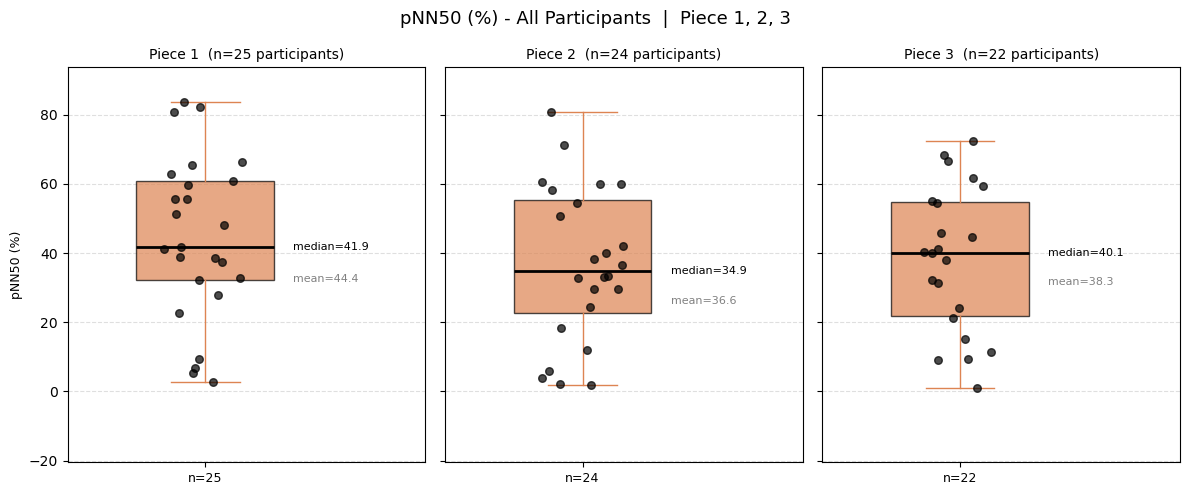

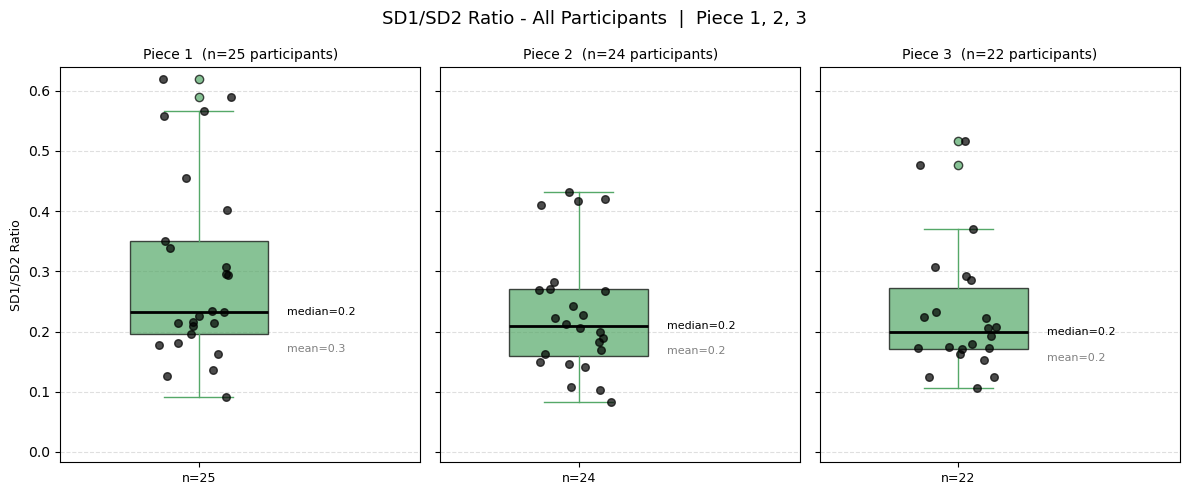

In [ ]:
import sys
import os
import re
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def run_all_participants(base_folder, sampling_rate=256):

    all_records = []

    range_folders = sorted([
        os.path.join(base_folder, f)
        for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f))
    ])
    print(f"[INFO] Found {len(range_folders)} range folders")

    for range_folder in range_folders:
        range_name = os.path.basename(range_folder)

        record_folders = [
            os.path.join(range_folder, f)
            for f in os.listdir(range_folder)
            if os.path.isdir(os.path.join(range_folder, f))
        ]

        for record_folder in record_folders:
            record_name = os.path.basename(record_folder)

            match = re.search(r'record_(\d+)', record_name)
            if not match:
                print(f"[SKIP] Could not parse record number from: {record_name}")
                continue
            participant_id = match.group(1)

            wav_file = os.path.join(record_folder, 'ECG_I.wav')
            if not os.path.exists(wav_file):
                print(f"[MISSING] {range_name}/{record_name} - no ECG_I.wav")
                continue

            print(f"[PROCESSING] Participant {participant_id} - {range_name}")

            try:
                if record_folder not in sys.path:
                    sys.path.insert(0, record_folder)
                import load_hx_data
                load_hx_data.set_device_model('hx')

                # Load ECG
                ecg_data  = load_hx_data.load_wave(wav_file)
                ecg       = pd.DataFrame(ecg_data, columns=['time', 'ECG'])
                ecg_numpy = ecg['ECG'].to_numpy()

                # Clean and detect peaks
                ecg_cleaned    = nk.ecg_clean(ecg_numpy, sampling_rate=sampling_rate)
                peaks_df, info = nk.ecg_peaks(
                    ecg_cleaned,
                    sampling_rate=sampling_rate,
                    correct_artifacts=True,
                    show=False
                )

                # Extract RR intervals from peak sample indices
                peak_samples = np.array(info['ECG_R_Peaks'], dtype=int)
                rr_raw       = np.diff(peak_samples) / sampling_rate * 1000

                # RR filtering - physiological window
                physio_mask = (rr_raw >= 300) & (rr_raw <= 2000)

                # RR filtering - rolling median
                rr_series   = pd.Series(rr_raw)
                rolling_med = rr_series.rolling(window=10, center=True, min_periods=3).median().to_numpy()
                deviation   = np.abs(rr_raw - rolling_med) / rolling_med
                median_mask = np.where(np.isnan(rolling_med), True, deviation < 0.20).astype(bool)

                clean_mask = physio_mask & median_mask
                rr_clean   = rr_raw[clean_mask]

                if len(rr_clean) < 20:
                    print(f"[SKIP] {range_name}/{record_name} - too few clean RR intervals ({len(rr_clean)})")
                    continue

                # Kubios correction - returns corrected RR intervals
                rr_corrected, artifacts, _ = nk.intervals_process(
                    rr_clean,
                    intervaltype="RR",
                    artifact_method="Kubios",
                    artifact_threshold=0.25
                )

                # Convert RR intervals back to peak indices for neurokit HRV functions
                peaks_corrected = nk.intervals_to_peaks(rr_corrected)

                # Compute HRV time domain metrics
                hrv_time      = nk.hrv_time(peaks_corrected, sampling_rate=sampling_rate, show=False)

                # Compute HRV nonlinear metrics - SD1, SD2 and SD1/SD2 ratio come directly from here
                hrv_nonlinear = nk.hrv_nonlinear(peaks_corrected, sampling_rate=sampling_rate, show=False)

                rmssd  = float(hrv_time['HRV_RMSSD'].values[0])
                pnn50  = float(hrv_time['HRV_pNN50'].values[0])
                # HRV_SD1SD2 is the SD1/SD2 ratio computed directly by hrv_nonlinear
                sd1sd2 = float(hrv_nonlinear['HRV_SD1SD2'].values[0])

                all_records.append({
                    'participant_id' : participant_id,
                    'range_folder'   : range_name,
                    'record_folder'  : record_name,
                    'RMSSD'          : rmssd,
                    'pNN50'          : pnn50,
                    'SD1_SD2_ratio'  : sd1sd2
                })

                print(f"  RMSSD={rmssd:.1f}  pNN50={pnn50:.1f}  SD1/SD2={sd1sd2:.3f}")

            except Exception as e:
                print(f"[ERROR] {range_name}/{record_name} - {e}")
                continue

    if not all_records:
        print("[WARN] No data collected.")
        return pd.DataFrame()

    df = pd.DataFrame(all_records)

    out_csv = os.path.join(base_folder, 'hrv_metrics_all_participants.csv')
    df.to_csv(out_csv, index=False)
    print(f"\n[SAVED] Metrics CSV: {out_csv}")
    print(df.to_string(index=False))

    plot_metric_across_participants(df, base_folder)

    return df


def plot_metric_across_participants(df, base_folder):
    """
    3 main figures - one per metric (RMSSD, pNN50, SD1SD2).
    Each figure has 3 subplots - one per piece (1st, 2nd, 3rd record folder per participant).
    Each box shows spread of all participant values for that piece.
    Piece number assigned by sorting range folders per participant.
    """

    metrics = ['RMSSD', 'pNN50', 'SD1_SD2_ratio']
    labels  = ['RMSSD (ms)', 'pNN50 (%)', 'SD1/SD2 Ratio']
    colors  = ['#4C72B0', '#DD8452', '#55A868']

    # Assign piece number per participant by sorting range folders
    df = df.copy()
    df['piece'] = df.groupby('participant_id')['range_folder'].rank(method='first').astype(int)

    for metric, label, color in zip(metrics, labels, colors):

        fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
        fig.suptitle(f'{label} - All Participants  |  Piece 1, 2, 3', fontsize=13)

        for piece_num, ax in zip([1, 2, 3], axes):

            values = df[df['piece'] == piece_num][metric].dropna().tolist()

            if not values:
                ax.set_title(f'Piece {piece_num}  no data')
                continue

            ax.boxplot(
                [values],
                positions=[1],
                widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=color),
                capprops=dict(color=color),
                flierprops=dict(marker='o', markerfacecolor=color,
                                markersize=6, alpha=0.7),
                manage_ticks=False
            )

            # Overlay individual participant points
            x_jitter = np.random.uniform(0.85, 1.15, size=len(values))
            ax.scatter(x_jitter, values, color='black', s=30, zorder=5, alpha=0.7)

            med = float(np.median(values))
            mn  = float(np.mean(values))
            sd  = float(np.std(values, ddof=1))

            ax.text(1.32, med, f'median={med:.1f}', va='center', fontsize=8)
            ax.text(1.32, med - sd * 0.4, f'mean={mn:.1f}',
                    va='center', fontsize=8, color='gray')

            y_min = min(values)
            y_max = max(values)
            y_pad = (y_max - y_min) * 0.3 if y_max != y_min else 1.0
            ax.set_ylim(y_min - y_pad, y_max + y_pad)

            ax.set_title(f'Piece {piece_num}  (n={len(values)} participants)', fontsize=10)
            ax.set_ylabel(label if piece_num == 1 else '', fontsize=9)
            ax.set_xticks([1])
            ax.set_xticklabels([f'n={len(values)}'], fontsize=9)
            ax.grid(axis='y', linestyle='--', alpha=0.4)
            ax.set_xlim(0.5, 1.8)

        plt.tight_layout()
        out_fig = os.path.join(base_folder, f'hrv_{metric}_pieces.png')
        plt.show()


# Run
base_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
df = run_all_participants(base_folder, sampling_rate=256)